ARTI308 - Machine Learning
# Seaborn Overview

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.




## Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

## Imports

In [7]:
# !pip install seaborn

In [8]:
import seaborn as sns       # Import seaborn for statistical plotting
# %matplotlib inline          # Render plots directly in the notebook

## Data
Seaborn comes with built-in data sets!

In [9]:
tips = sns.load_dataset('tips')  # Load the built-in tips dataset

In [10]:
tips.head()  # Preview the first 5 rows of the dataset

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## distplot

The distplot shows the distribution of a univariate set of observations.

C:\Users\mmahf\AppData\Local\Temp\ipykernel_18792\2436034260.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'])  # Plot distribution of total_bill with KDE overlay


<Axes: xlabel='total_bill', ylabel='Density'>

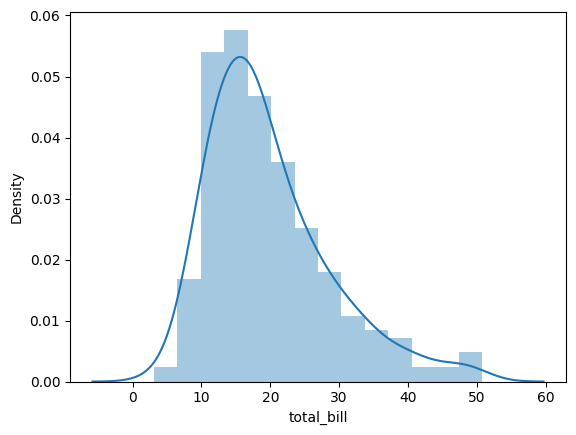

In [11]:
sns.distplot(tips['total_bill'])  # Plot distribution of total_bill with KDE overlay
# Safe to ignore warnings

To remove the kde layer and just have the histogram use:

C:\Users\mmahf\AppData\Local\Temp\ipykernel_18792\3956442555.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'], kde=False, bins=30)  # Histogram only, no KDE, with 30 bins


<Axes: xlabel='total_bill'>

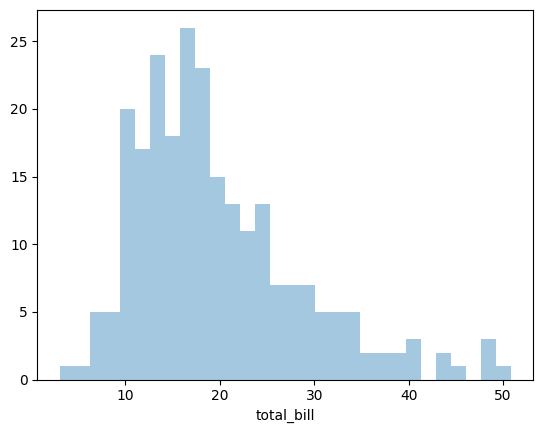

In [12]:
sns.distplot(tips['total_bill'], kde=False, bins=30)  # Histogram only, no KDE, with 30 bins

## jointplot

jointplot() allows you to basically match up two distplots for bivariate data. With your choice of what **kind** parameter to compare with: 
* “scatter” 
* “reg” 
* “resid” 
* “kde” 
* “hex”

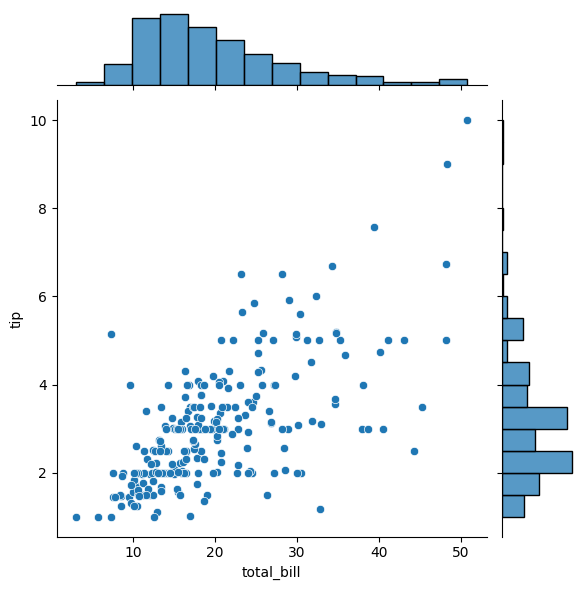

In [13]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='scatter')  # Scatter jointplot of bill vs tip

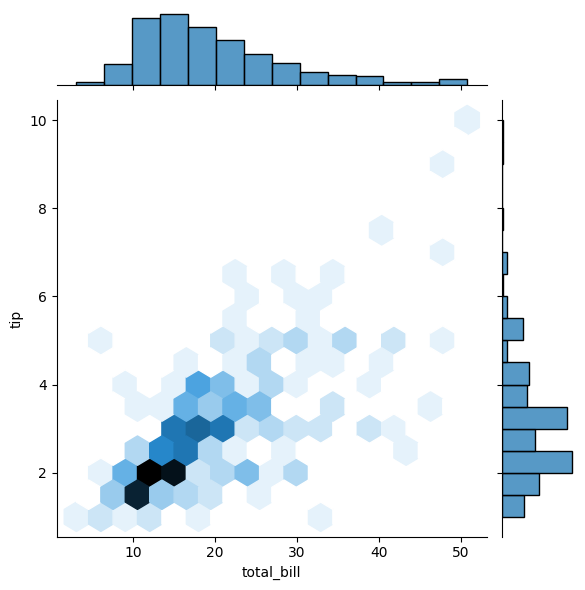

In [14]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='hex')  # Hex-bin jointplot to show density

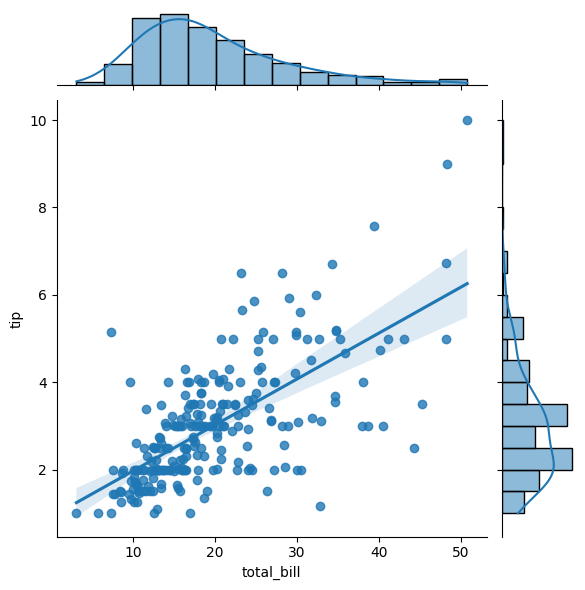

In [15]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')  # Jointplot with linear regression fit

## pairplot

pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and supports a color hue argument (for categorical columns). 

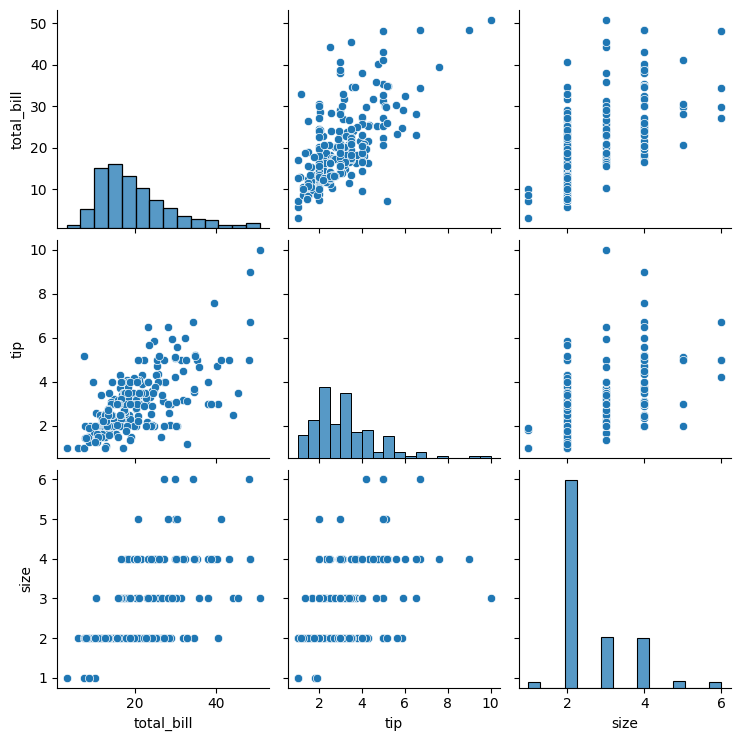

In [16]:
sns.pairplot(tips)  # Plot pairwise relationships for all numeric columns

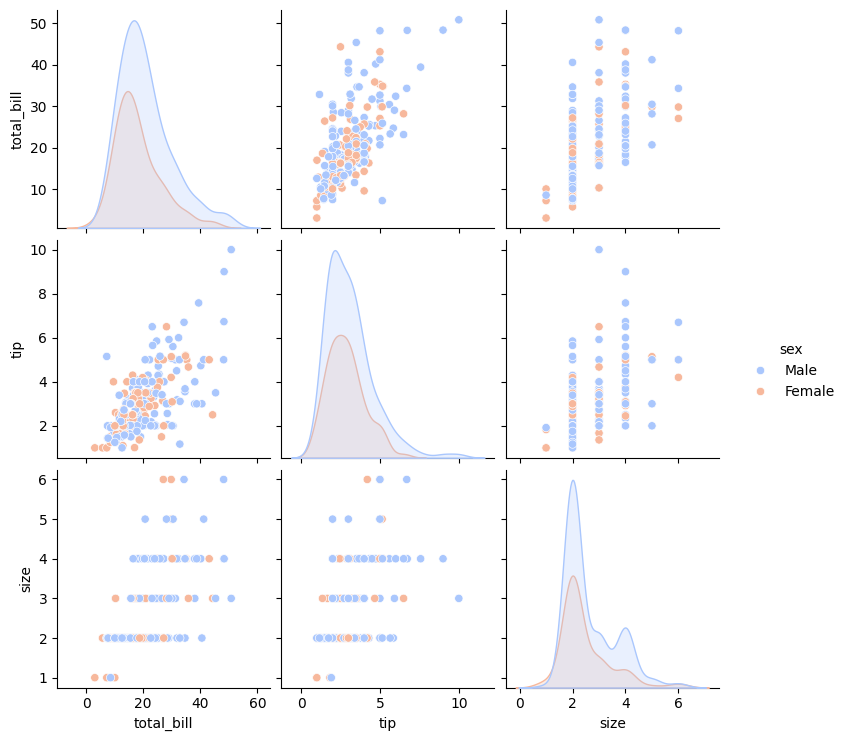

In [17]:
sns.pairplot(tips, hue='sex', palette='coolwarm')  # Pairplot with points colored by sex

## rugplot

rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:

<Axes: xlabel='total_bill'>

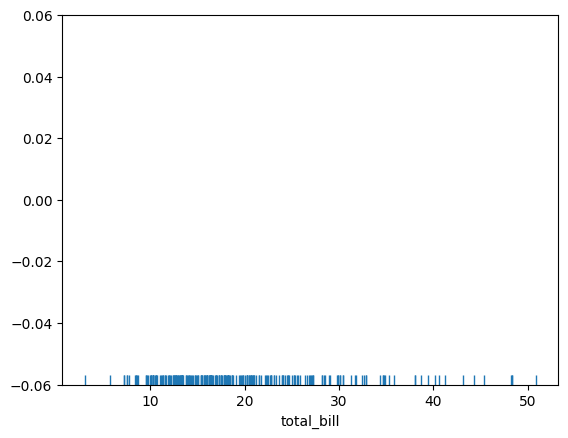

In [18]:
sns.rugplot(tips['total_bill'])  # Draw a tick mark for each observation along the axis

## kdeplot

kdeplots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:

In [20]:
!pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.0/37.3 MB 2.7 MB/s eta 0:00:14
   -- ------------------------------------- 2.1/37.3 MB 3.4 MB/s eta 0:00:11
   --- ------------------------------------ 3.1/37.3 MB 3.9 MB/s eta 0:00:09
   ---- ----------------------------------- 3.9/37.3 MB 3.9 MB/s eta 0:00:09
   ----- ---------------------------------- 5.2/37.3 MB 4.3 MB/s eta 0:00:08
   ------ --------------------------------- 6.3/37.3 MB 4.5 MB/s eta 0:00:07
   -------- ------------------------------- 7.9/37.3 MB 4.8 MB/s eta 0:00:07
   --------- ------------------------------ 8.7/37.3 MB 4.7 MB/s eta 0:00:07
   ---------- ----------------------------- 9.4/37.3 MB 4.6 MB/s eta 0:00:07
   ---------- ----------------------------- 9.4/37.3 MB 4.6 MB/s eta 0:00:07
   ---------- ------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


(0.0, 1.0)

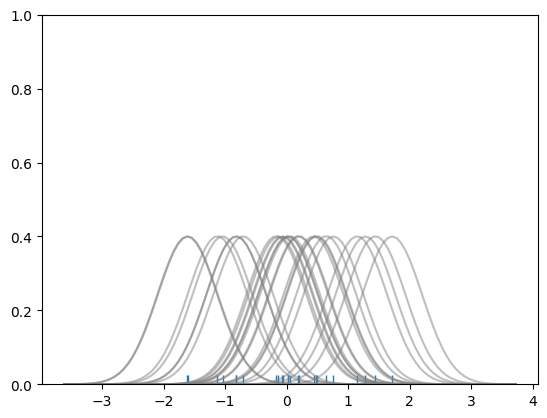

In [21]:
# Don't worry about understanding this code!
# It's just for the diagram below
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Create dataset
dataset = np.random.randn(25)       # Generate 25 random values from a normal distribution

# Create another rugplot
sns.rugplot(dataset);               # Draw tick marks for each data point

# Set up the x-axis for the plot
x_min = dataset.min() - 2          # Extend x-axis slightly beyond the min value
x_max = dataset.max() + 2          # Extend x-axis slightly beyond the max value

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min, x_max, 100)  # Create smooth x range for plotting curves

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2  # Silverman's rule of thumb for bandwidth


# Create an empty kernel list
kernel_list = []                    # Will hold individual Gaussian curves for each point

# Plot each basis function
for data_point in dataset:

    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point, bandwidth).pdf(x_axis)  # Gaussian centered on this data point
    kernel_list.append(kernel)

    # Scale for plotting
    kernel = kernel / kernel.max()  # Normalize kernel height to 1
    kernel = kernel * .4            # Scale down so curves don't overlap too much
    plt.plot(x_axis, kernel, color='grey', alpha=0.5)  # Plot each kernel in grey

plt.ylim(0, 1)  # Fix y-axis range for consistent display

Text(0.5, 0.98, 'Sum of the Basis Functions')

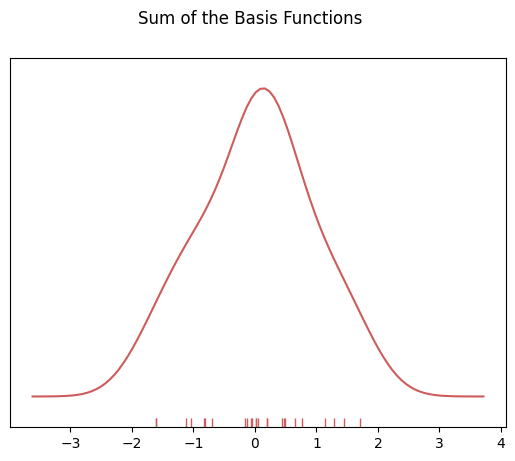

In [22]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list, axis=0)  # Sum all kernels to form the KDE curve

# Plot figure
fig = plt.plot(x_axis, sum_of_kde, color='indianred')  # Draw the final KDE line

# Add the initial rugplot
sns.rugplot(dataset, c='indianred')  # Overlay individual data points as tick marks

# Get rid of y-tick marks
plt.yticks([])  # Hide y-axis ticks since absolute density values aren't meaningful here

# Set title
plt.suptitle("Sum of the Basis Functions")  # Add overall title to the figure

So with our tips dataset:

<Axes: xlabel='total_bill', ylabel='Density'>

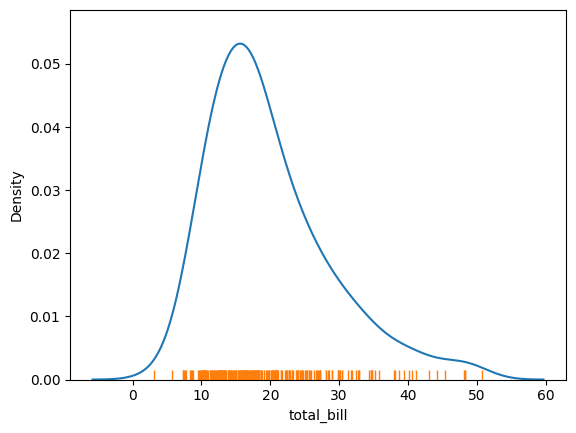

In [23]:
sns.kdeplot(tips['total_bill'])   # Draw KDE curve for total_bill distribution
sns.rugplot(tips['total_bill'])   # Overlay tick marks for each observation

<Axes: xlabel='tip', ylabel='Density'>

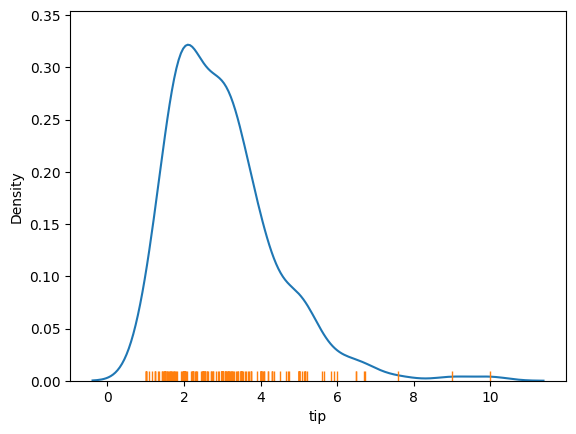

In [24]:
sns.kdeplot(tips['tip'])   # Draw KDE curve for tip distribution
sns.rugplot(tips['tip'])   # Overlay tick marks for each observation

# Categorical Data Plots

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* factorplot
* boxplot
* violinplot
* stripplot
* swarmplot
* barplot
* countplot

Let's go through examples of each!

In [25]:
import seaborn as sns  # Import seaborn for statistical plotting
%matplotlib inline     # Render plots directly in the notebook

UsageError: unrecognized arguments: # Render plots directly in the notebook


In [26]:
tips = sns.load_dataset('tips')  # Reload the tips dataset
tips.head()                      # Preview the first 5 rows

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## barplot and countplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. **barplot** is a general plot that allows you to aggregate the categorical data based off some function, by default the mean:

<Axes: xlabel='sex', ylabel='total_bill'>

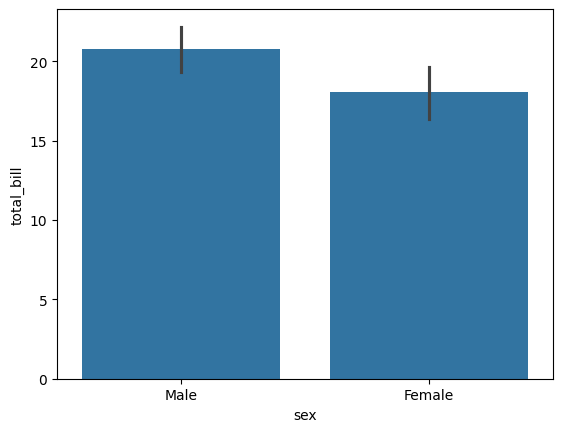

In [27]:
sns.barplot(x='sex', y='total_bill', data=tips)  # Bar plot of mean total_bill grouped by sex

In [28]:
import numpy as np  # Import numpy for numerical functions like std

You can change the estimator object to your own function, that converts a vector to a scalar:

<Axes: xlabel='sex', ylabel='total_bill'>

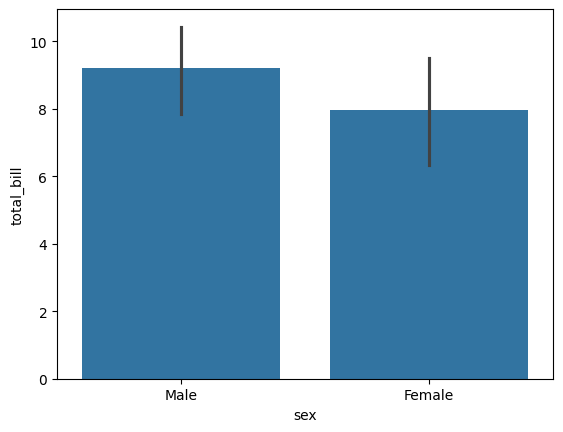

In [29]:
sns.barplot(x='sex', y='total_bill', data=tips, estimator=np.std)  # Bar plot using std deviation instead of mean

### countplot

This is essentially the same as barplot except the estimator is explicitly counting the number of occurrences. Which is why we only pass the x value:

<Axes: xlabel='sex', ylabel='count'>

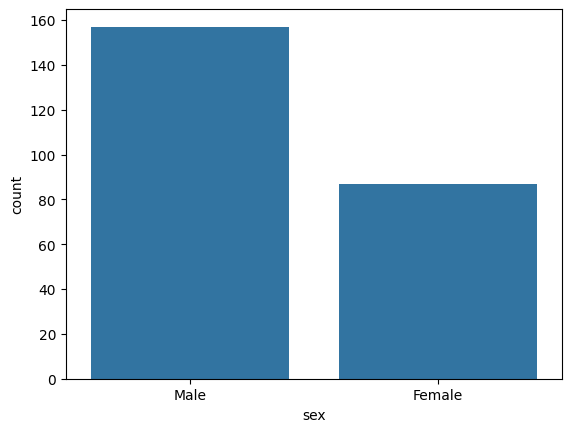

In [30]:
sns.countplot(x='sex', data=tips)  # Count the number of occurrences of each sex category

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

C:\Users\mmahf\AppData\Local\Temp\ipykernel_18792\1021167499.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day", y="total_bill", data=tips, palette='rainbow')  # Box plot of total_bill per day


<Axes: xlabel='day', ylabel='total_bill'>

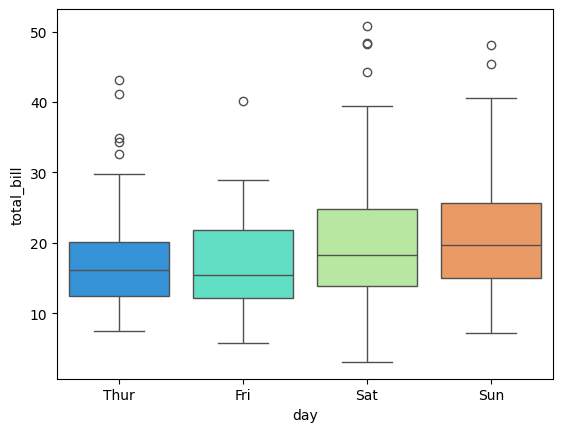

In [31]:
sns.boxplot(x="day", y="total_bill", data=tips, palette='rainbow')  # Box plot of total_bill per day

<Axes: >

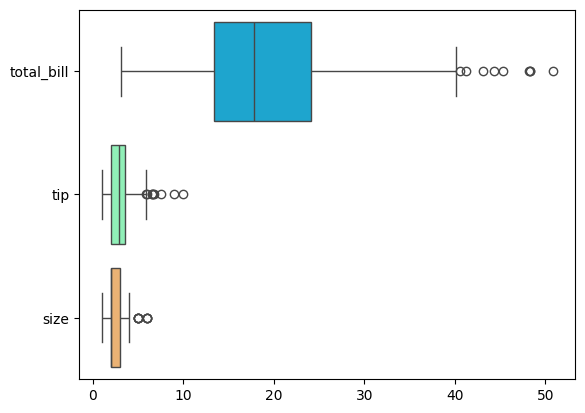

In [32]:
# Can do entire dataframe with orient='h'
sns.boxplot(data=tips, palette='rainbow', orient='h')  # Horizontal box plots for all numeric columns

<Axes: xlabel='day', ylabel='total_bill'>

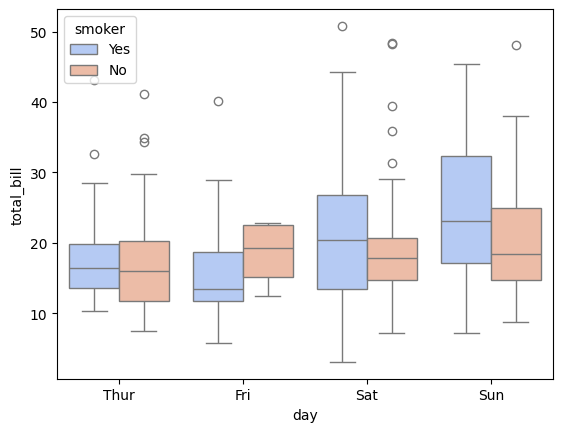

In [33]:
sns.boxplot(x="day", y="total_bill", hue="smoker", data=tips, palette="coolwarm")  # Box plot split by smoker status

### violinplot
A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

C:\Users\mmahf\AppData\Local\Temp\ipykernel_18792\4066382488.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="day", y="total_bill", data=tips, palette='rainbow')  # Violin plot showing distribution shape per day


<Axes: xlabel='day', ylabel='total_bill'>

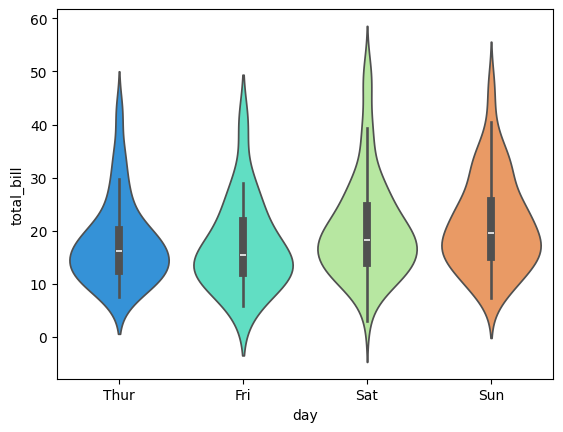

In [34]:
sns.violinplot(x="day", y="total_bill", data=tips, palette='rainbow')  # Violin plot showing distribution shape per day

<Axes: xlabel='day', ylabel='total_bill'>

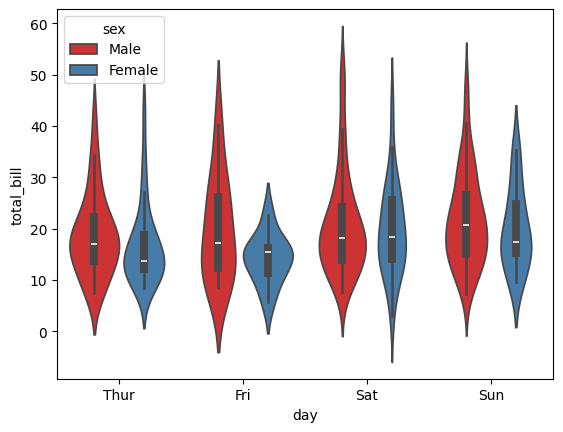

In [35]:
sns.violinplot(x="day", y="total_bill", data=tips, hue='sex', palette='Set1')  # Violin split by sex with separate violins

<Axes: xlabel='day', ylabel='total_bill'>

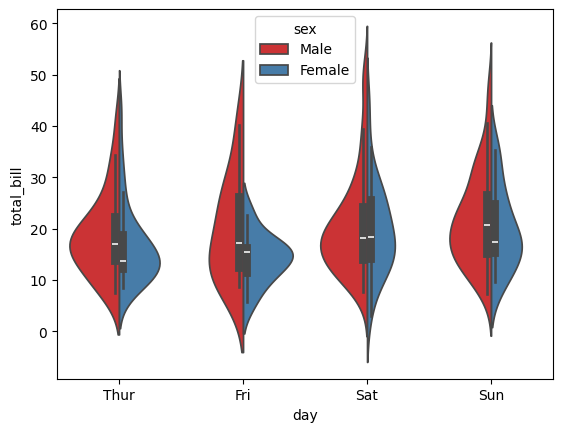

In [36]:
sns.violinplot(x="day", y="total_bill", data=tips, hue='sex', split=True, palette='Set1')  # Split violin: male/female on each half

## stripplot and swarmplot
The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

The swarmplot is similar to stripplot(), but the points are adjusted (only along the categorical axis) so that they don’t overlap. This gives a better representation of the distribution of values, although it does not scale as well to large numbers of observations (both in terms of the ability to show all the points and in terms of the computation needed to arrange them).

C:\Users\mmahf\AppData\Local\Temp\ipykernel_18792\3057988878.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow')  # Scatter each observation along the categorical axis


<Axes: xlabel='day', ylabel='total_bill'>

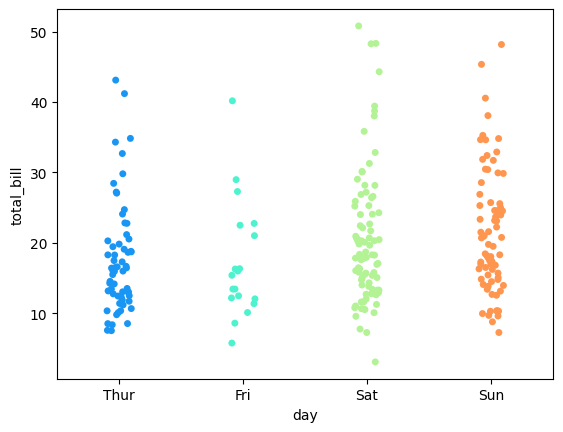

In [37]:
sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow')  # Scatter each observation along the categorical axis

C:\Users\mmahf\AppData\Local\Temp\ipykernel_18792\274966578.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips, jitter=True, palette='rainbow')  # Add jitter to reduce point overlap


<Axes: xlabel='day', ylabel='total_bill'>

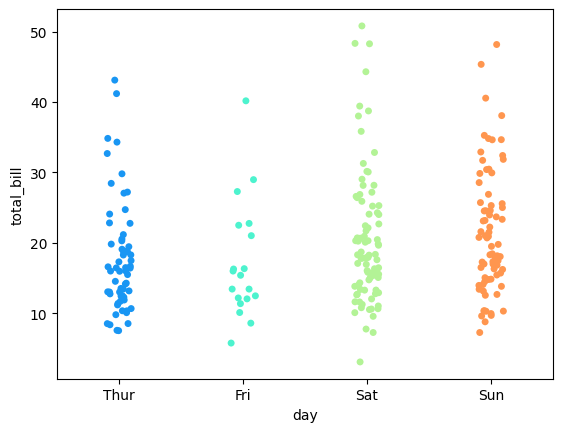

In [38]:
sns.stripplot(x="day", y="total_bill", data=tips, jitter=True, palette='rainbow')  # Add jitter to reduce point overlap

<Axes: xlabel='day', ylabel='total_bill'>

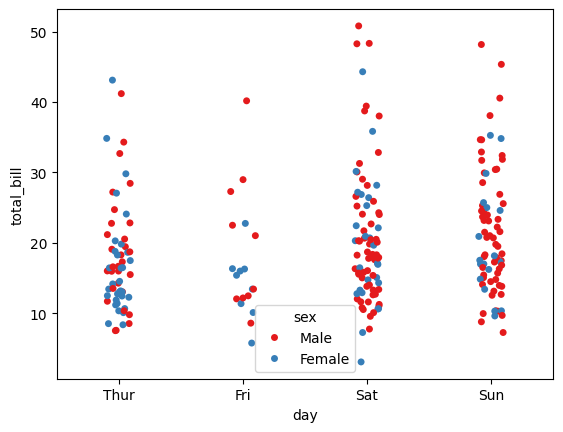

In [39]:
sns.stripplot(x="day", y="total_bill", data=tips, jitter=True, hue='sex', palette='Set1')  # Color points by sex

<Axes: xlabel='day', ylabel='total_bill'>

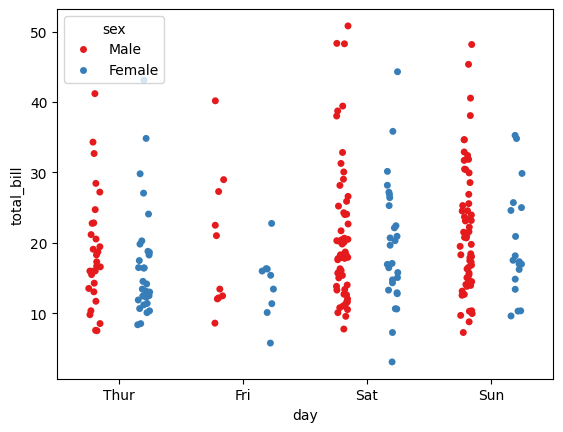

In [40]:
sns.stripplot(x="day", y="total_bill", data=tips, jitter=True, hue='sex', palette='Set1', dodge=True)  # Separate strips by sex side by side

<Axes: xlabel='day', ylabel='total_bill'>

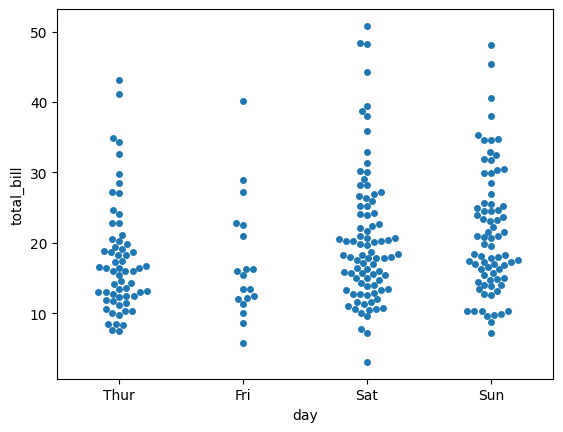

In [41]:
sns.swarmplot(x="day", y="total_bill", data=tips)  # Like stripplot but points are adjusted to avoid overlap

### Combining Categorical Plots

C:\Users\mmahf\AppData\Local\Temp\ipykernel_18792\341566694.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="tip", y="day", data=tips, palette='rainbow')        # Base violin plot for distribution shape


<Axes: xlabel='tip', ylabel='day'>

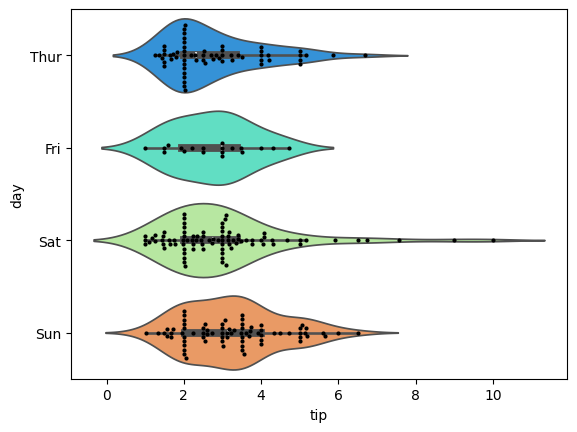

In [42]:
sns.violinplot(x="tip", y="day", data=tips, palette='rainbow')        # Base violin plot for distribution shape
sns.swarmplot(x="tip", y="day", data=tips, color='black', size=3)     # Overlay individual points on top of violin

## catplot

factorplot is the most general form of a categorical plot. It can take in a kind parameter to adjust the plot type:

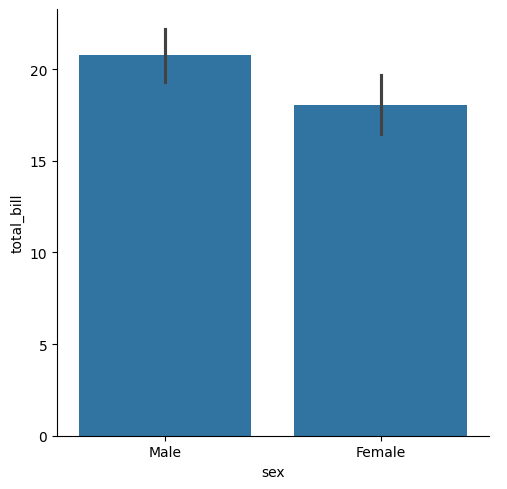

In [43]:
sns.catplot(x='sex', y='total_bill', data=tips, kind='bar')  # General categorical plot, here as a bar chart

# Matrix Plots

Matrix plots allow you to plot data as color-encoded matrices and can also be used to indicate clusters within the data (later in the machine learning section we will learn how to formally cluster data).

Let's begin by exploring seaborn's heatmap and clutermap:

In [44]:
import seaborn as sns  # Import seaborn for statistical plotting
%matplotlib inline     # Render plots directly in the notebook

UsageError: unrecognized arguments: # Render plots directly in the notebook


In [45]:
flights = sns.load_dataset('flights')  # Load the built-in flights dataset (monthly passenger counts)

In [46]:
tips = sns.load_dataset('tips')  # Reload the tips dataset

In [47]:
tips.head()  # Preview the first 5 rows of tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [48]:
flights.head()  # Preview the first 5 rows of flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Heatmap

In order for a heatmap to work properly, your data should already be in a matrix form, the sns.heatmap function basically just colors it in for you. For example:

In [49]:
tips.head()  # Verify tips data before building the heatmap

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [50]:
# Matrix form for correlation data
tips.corr()  # Compute pairwise correlation between numeric columns

ValueError: could not convert string to float: 'No'

In [ ]:
sns.heatmap(tips.corr())  # Visualize correlation matrix as a color-coded heatmap

In [ ]:
sns.heatmap(tips.corr(), cmap='coolwarm', annot=True)  # Heatmap with coolwarm colors and correlation values annotated

Or for the flights data:

In [51]:
flights.pivot_table(values='passengers', index='month', columns='year')  # Reshape flights into a month x year matrix

C:\Users\mmahf\AppData\Local\Temp\ipykernel_18792\661483266.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights.pivot_table(values='passengers', index='month', columns='year')  # Reshape flights into a month x year matrix


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


C:\Users\mmahf\AppData\Local\Temp\ipykernel_18792\3204563961.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvflights = flights.pivot_table(values='passengers', index='month', columns='year')  # Pivot flights into month x year matrix


<Axes: xlabel='year', ylabel='month'>

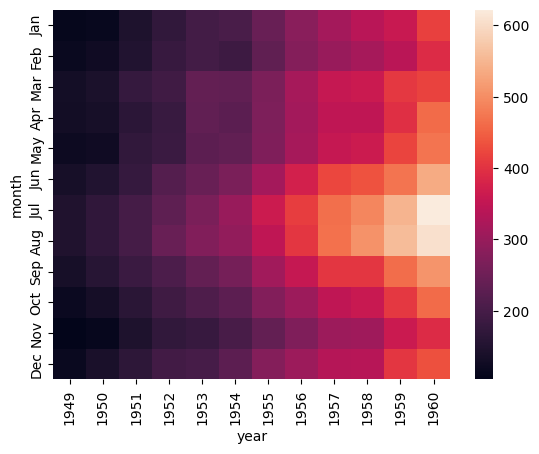

In [52]:
pvflights = flights.pivot_table(values='passengers', index='month', columns='year')  # Pivot flights into month x year matrix
sns.heatmap(pvflights)  # Plot passenger counts as a heatmap

<Axes: xlabel='year', ylabel='month'>

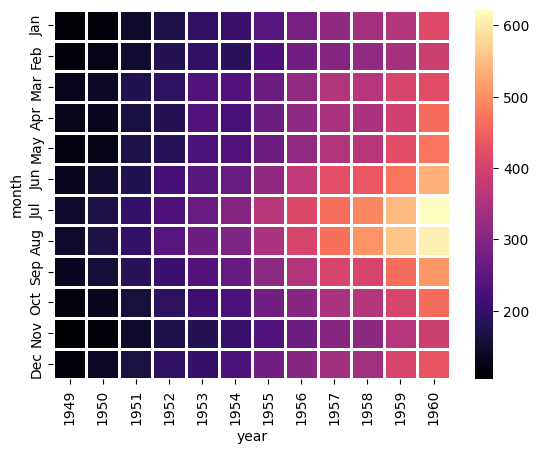

In [53]:
sns.heatmap(pvflights, cmap='magma', linecolor='white', linewidths=1)  # Heatmap with magma palette and white grid lines between cells

## clustermap

The clustermap uses hierarchal clustering to produce a clustered version of the heatmap. For example:

In [54]:
sns.clustermap(pvflights)  # Hierarchically cluster rows and columns, then display as heatmap

RuntimeError: clustermap requires scipy to be available

Notice now how the years and months are no longer in order, instead they are grouped by similarity in value (passenger count). That means we can begin to infer things from this plot, such as August and July being similar (makes sense, since they are both summer travel months)

In [55]:
# More options to get the information a little clearer like normalization
sns.clustermap(pvflights, standard_scale=1)  # Normalize each column to [0,1] before clustering

RuntimeError: clustermap requires scipy to be available

# Regression Plots

Seaborn has many built-in capabilities for regression plots, however we won't really discuss regression until the machine learning section of the course, so we will only cover the **lmplot()** function for now.

**lmplot** allows you to display linear models, but it also conveniently allows you to split up those plots based off of features, as well as coloring the hue based off of features.

Let's explore how this works:

In [56]:
import seaborn as sns  # Import seaborn for statistical plotting
%matplotlib inline     # Render plots directly in the notebook

UsageError: unrecognized arguments: # Render plots directly in the notebook


In [57]:
tips = sns.load_dataset('tips')  # Load the tips dataset for regression examples

In [58]:
tips.head()  # Preview the first 5 rows

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## lmplot()

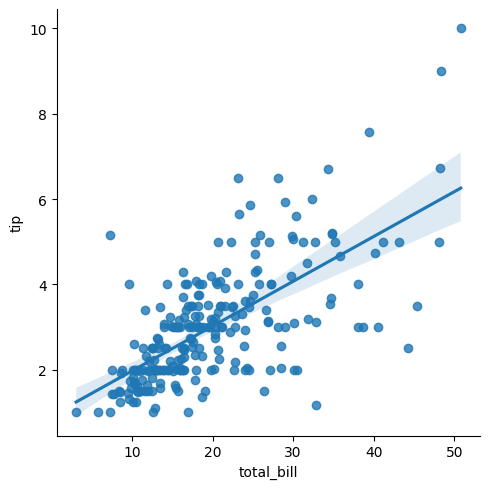

In [59]:
sns.lmplot(x='total_bill', y='tip', data=tips)  # Scatter plot with a linear regression line

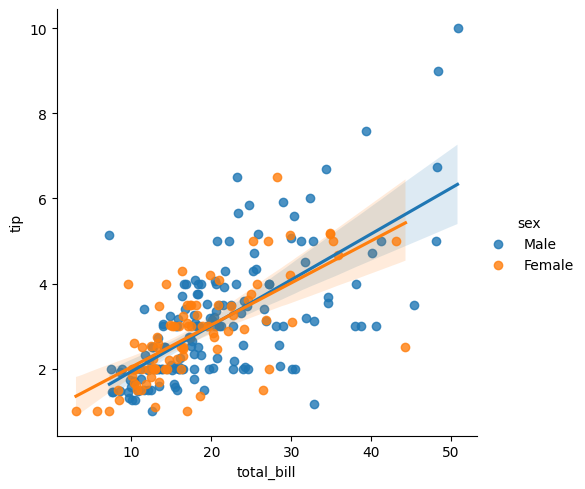

In [60]:
sns.lmplot(x='total_bill', y='tip', data=tips, hue='sex')  # Separate regression lines colored by sex

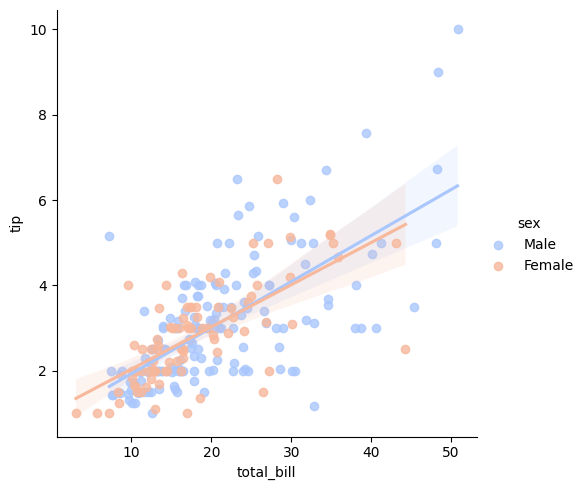

In [61]:
sns.lmplot(x='total_bill', y='tip', data=tips, hue='sex', palette='coolwarm')  # Same but with coolwarm color palette

## Using a Grid

We can add more variable separation through columns and rows with the use of a grid. Just indicate this with the col or row arguments:

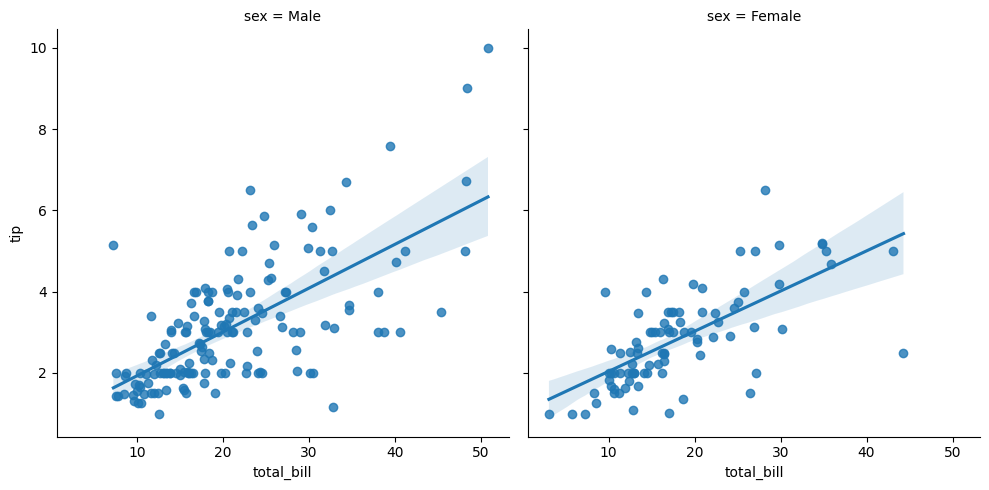

In [62]:
sns.lmplot(x='total_bill', y='tip', data=tips, col='sex')  # Side-by-side plots split by sex column

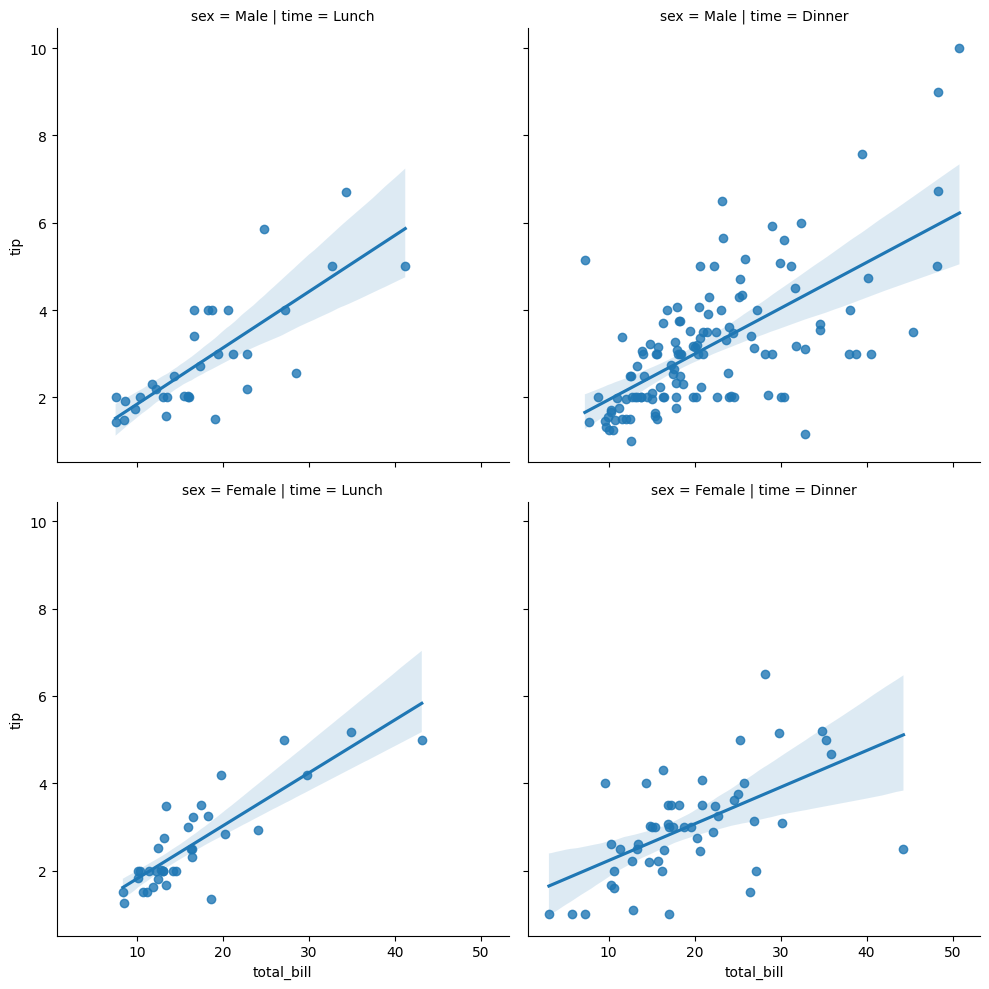

In [63]:
sns.lmplot(x="total_bill", y="tip", row="sex", col="time", data=tips)  # Grid of plots split by sex (rows) and time (columns)

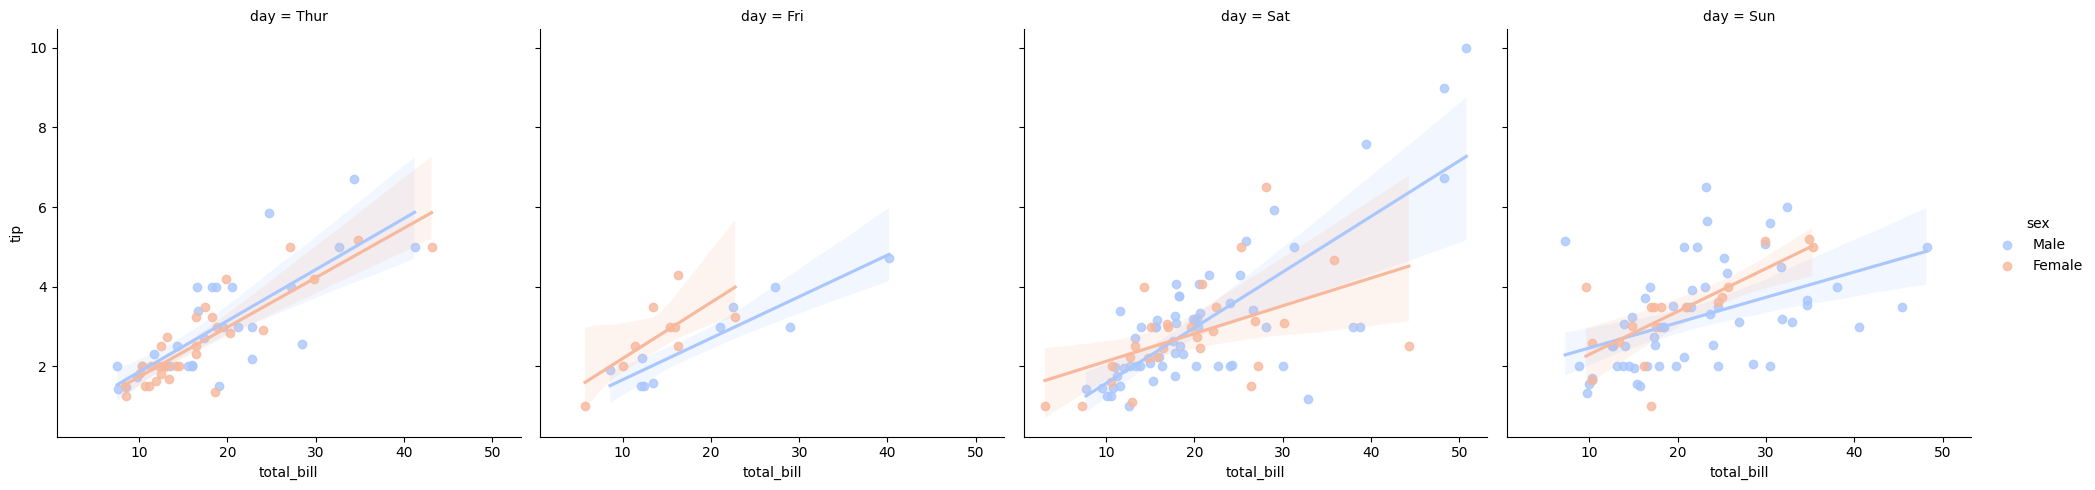

In [64]:
sns.lmplot(x='total_bill', y='tip', data=tips, col='day', hue='sex', palette='coolwarm')  # One plot per day, colored by sex

## Aspect and Size

Seaborn figures can have their size and aspect ratio adjusted with the **height** and **aspect** parameters:

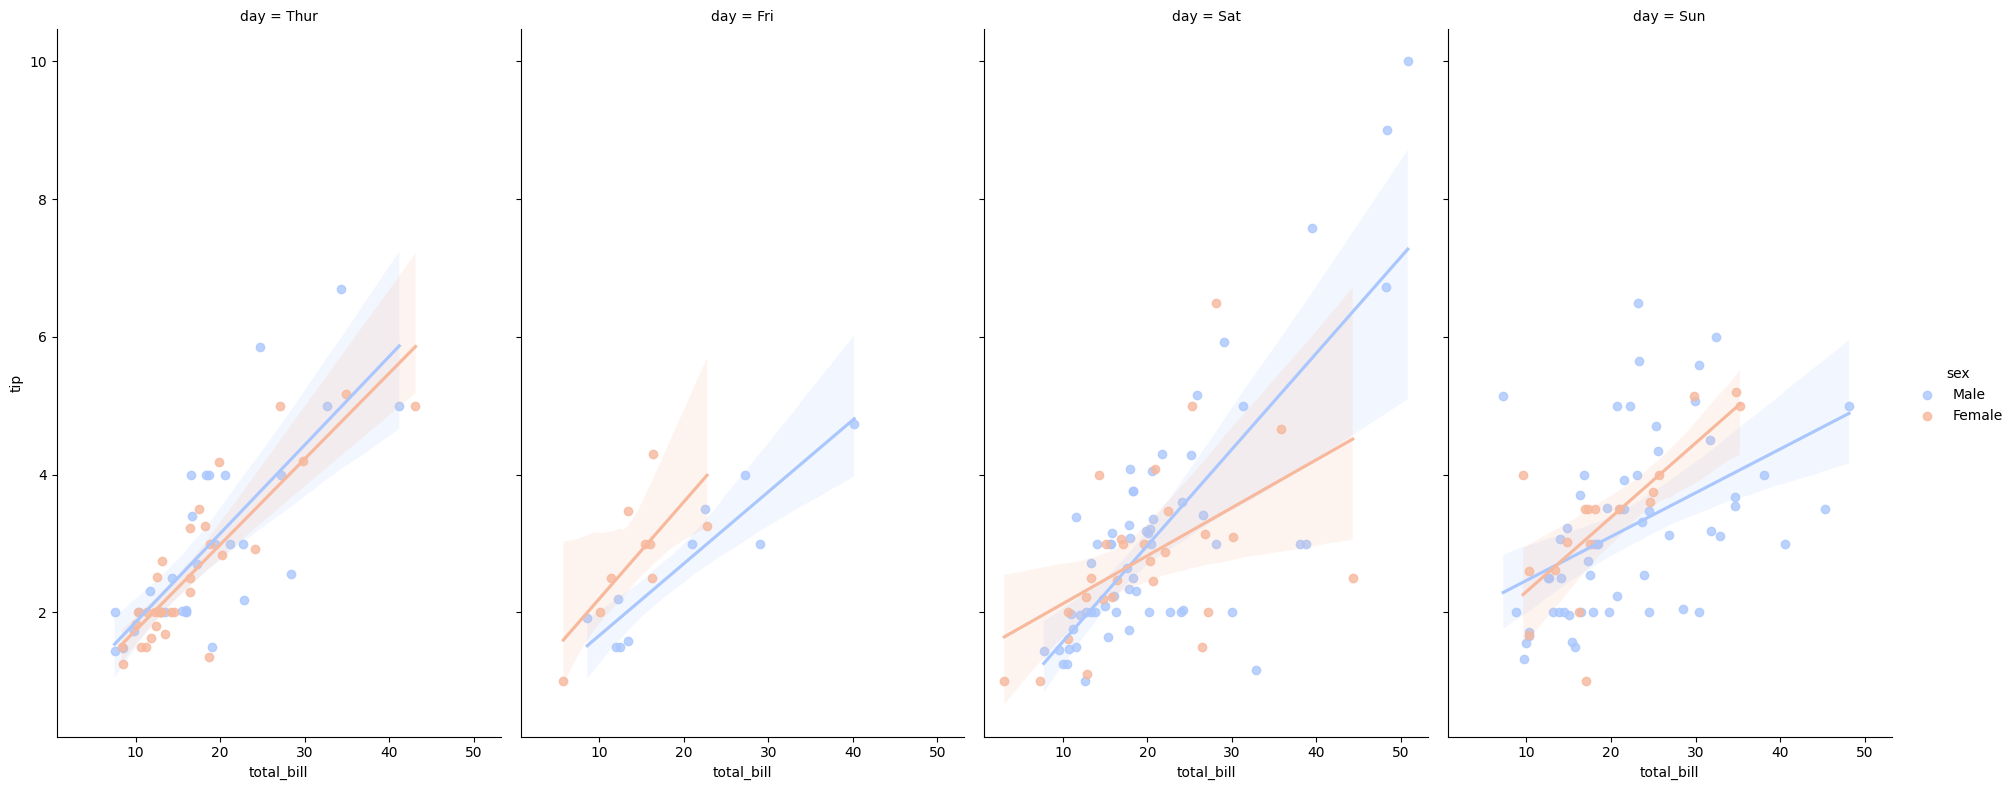

In [65]:
sns.lmplot(x='total_bill', y='tip', data=tips, col='day', hue='sex', palette='coolwarm',
           aspect=0.6, height=8)  # Tall narrow subplots per day with custom aspect ratio and height

### Reference:

* https://seaborn.pydata.org/ - Seaborn: statistical data visualization


* https://seaborn.pydata.org/tutorial/color_palettes.html - Color palettes